# Credit Card Clustering

### Veri Seti Değişken Açıklamaları

- **CUST_ID:** Kredi kartı sahibinin müşteri kimlik numarası.
- **BALANCE:** Kart sahibinin hesabında kalan borç bakiyesi.
- **BALANCE_FREQUENCY:** Bakiyenin ne sıklıkla güncellendiğini gösterir (0–1 arası). 1 = sık güncellenir.
- **PURCHASES:** Kart ile yapılan toplam alışveriş miktarı.
- **ONEOFF_PURCHASES:** Tek seferde yapılan alışverişlerin toplam tutarı.
- **INSTALLMENTS_PURCHASES:** Taksitli yapılan alışverişlerin toplam tutarı.
- **CASH_ADVANCE:** Karttan çekilen toplam nakit avans miktarı.
- **PURCHASES_FREQUENCY:** Alışveriş yapılma sıklığı (0–1 arası).
- **ONEOFFPURCHASESFREQUENCY:** Tek seferlik alışverişlerin yapılma sıklığı.
- **PURCHASESINSTALLMENTSFREQUENCY:** Taksitli alışverişlerin yapılma sıklığı.
- **CASHADVANCEFREQUENCY:** Nakit avans çekme sıklığı.
- **CASHADVANCETRX:** Yapılan nakit avans işlem sayısı.
- **PURCHASES_TRX:** Toplam alışveriş işlem sayısı.
- **CREDIT_LIMIT:** Kullanıcının kredi kartı limiti.
- **PAYMENTS:** Kullanıcının yaptığı toplam ödeme miktarı.
- **MINIMUM_PAYMENTS:** Kullanıcının yaptığı minimum ödeme miktarı.
- **PRC_FULL_PAYMENT:** Borcun tamamının ödenme yüzdesi.
- **TENURE:** Kredi kartının kullanım süresi (ay olarak).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn import cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import linkage, dendrogram

from joblib import dump
from tensorflow.keras.models import load_model
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [2]:
df=pd.read_csv('CC GENERAL.csv')

### EDA - Exploratory Data Analysis

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
df.shape

(8950, 18)

In [6]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [7]:
df=df.dropna()

In [8]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,1601.224893,0.895035,1025.433874,604.901438,420.843533,994.175523,0.496000,0.205909,0.368820,0.137604,3.313918,15.033233,4522.091030,1784.478099,864.304943,0.159304,11.534391
std,2095.571300,0.207697,2167.107984,1684.307803,917.245182,2121.458303,0.401273,0.300054,0.398093,0.201791,6.912506,25.180468,3659.240379,2909.810090,2372.566350,0.296271,1.310984
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163,0.000000,6.000000
25%,148.095189,0.909091,43.367500,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,418.559237,169.163545,0.000000,12.000000
50%,916.855459,1.000000,375.405000,44.995000,94.785000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,896.675701,312.452292,0.000000,12.000000
75%,2105.195853,1.000000,1145.980000,599.100000,484.147500,1132.385490,0.916667,0.333333,0.750000,0.250000,4.000000,18.000000,6500.000000,1951.142090,825.496463,0.166667,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [9]:
df1=df[["BALANCE", "PURCHASES", "CREDIT_LIMIT"]]

In [10]:
df1.head()

,BALANCE,PURCHASES,CREDIT_LIMIT
0,40.900749,95.40,1000.0
1,3202.467416,0.00,7000.0
2,2495.148862,773.17,7500.0
4,817.714335,16.00,1200.0
5,1809.828751,1333.28,1800.0


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8636 entries, 0 to 8949
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   BALANCE       8636 non-null   float64
 1   PURCHASES     8636 non-null   float64
 2   CREDIT_LIMIT  8636 non-null   float64
dtypes: float64(3)
memory usage: 269.9 KB


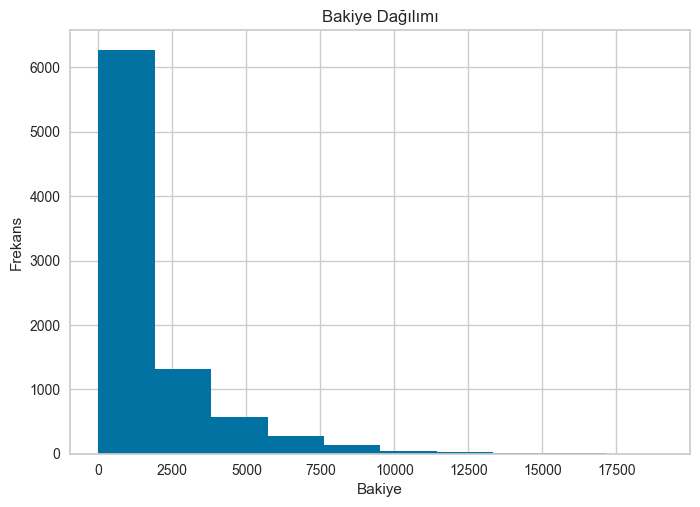

In [12]:
plt.figure()
df["BALANCE"].hist()
plt.title("Bakiye Dağılımı")
plt.xlabel("Bakiye")
plt.ylabel("Frekans")
plt.show()

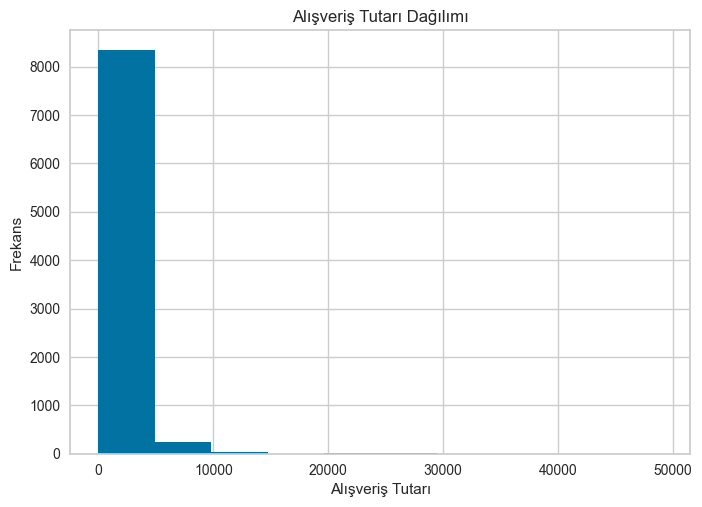

In [13]:
plt.figure()
df["PURCHASES"].hist()
plt.title("Alışveriş Tutarı Dağılımı")
plt.xlabel("Alışveriş Tutarı")
plt.ylabel("Frekans")
plt.show()

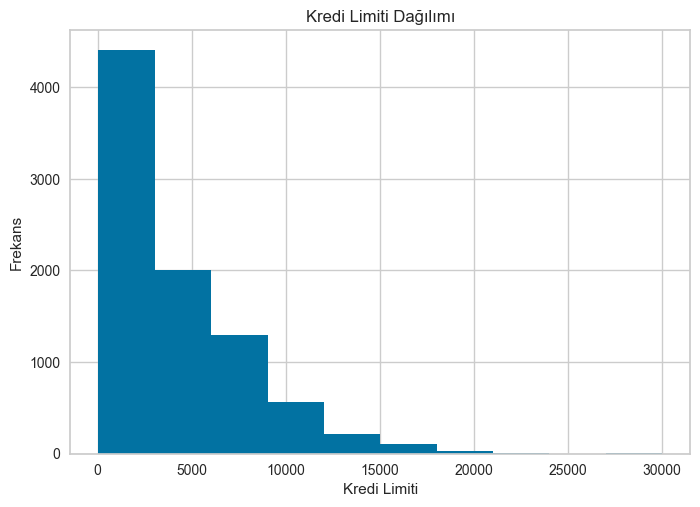

In [14]:
plt.figure()
df["CREDIT_LIMIT"].hist()
plt.title("Kredi Limiti Dağılımı")
plt.xlabel("Kredi Limiti")
plt.ylabel("Frekans")
plt.show()

### Model and Testing

In [15]:
model=KMeans(4)

In [16]:
model=model.fit(df1)

In [17]:
tahmin=model.predict(df1)

In [18]:
df1['cluster']=tahmin

In [19]:
df1.head()

,BALANCE,PURCHASES,CREDIT_LIMIT,cluster
0,40.900749,95.40,1000.0,0
1,3202.467416,0.00,7000.0,2
2,2495.148862,773.17,7500.0,2
4,817.714335,16.00,1200.0,0
5,1809.828751,1333.28,1800.0,0


In [20]:
silhouette_score(df1, tahmin)

0.46944036581768084

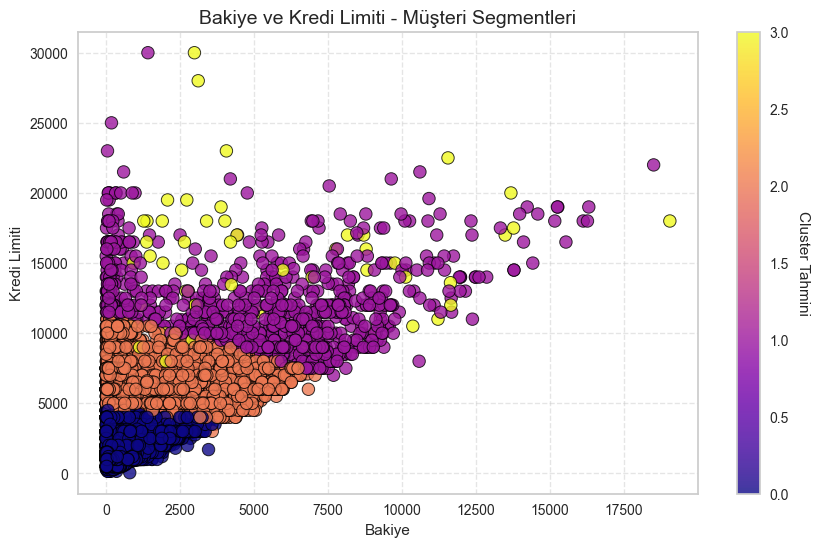

In [21]:
plt.figure(figsize=(10,6))

# Scatter plot
sc = plt.scatter(df['BALANCE'], df['CREDIT_LIMIT'], 
                 c=tahmin,                 # renk = tahmin (cluster)
                 cmap='plasma',             # daha canlı renk paleti
                 s=80,                      # nokta boyutu
                 alpha=0.8, 
                 edgecolor='black',         # kenarlık
                 linewidth=0.7)

# Renk skalası
cbar = plt.colorbar(sc)
cbar.set_label('Cluster Tahmini', rotation=270, labelpad=15)

# Ekseni ve başlık
plt.xlabel('Bakiye')
plt.ylabel('Kredi Limiti')
plt.title('Bakiye ve Kredi Limiti - Müşteri Segmentleri', fontsize=14)

# Grid ekle
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [22]:
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(df1)
    tahmin=model.predict(df1)
    ss1=silhouette_score(df1,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.5439257655380618
0.48259000274358244
0.47170715304552874
0.4579422774639376
0.4308785765630234
0.3968113579496023
0.36896991164300663
0.36075714955484306


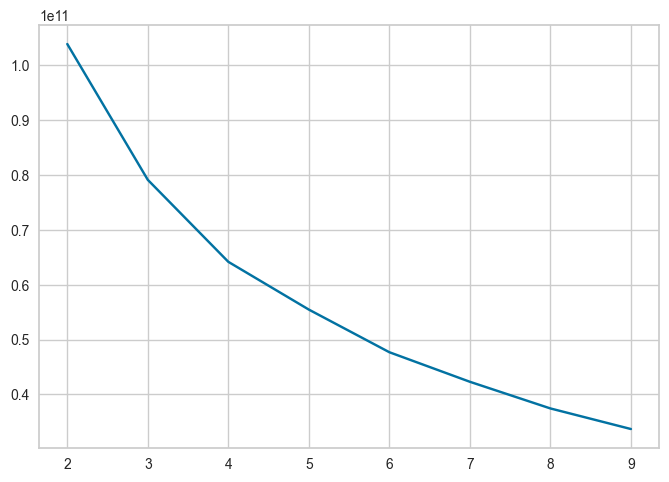

In [23]:
plt.plot(range(2,10),wcss)

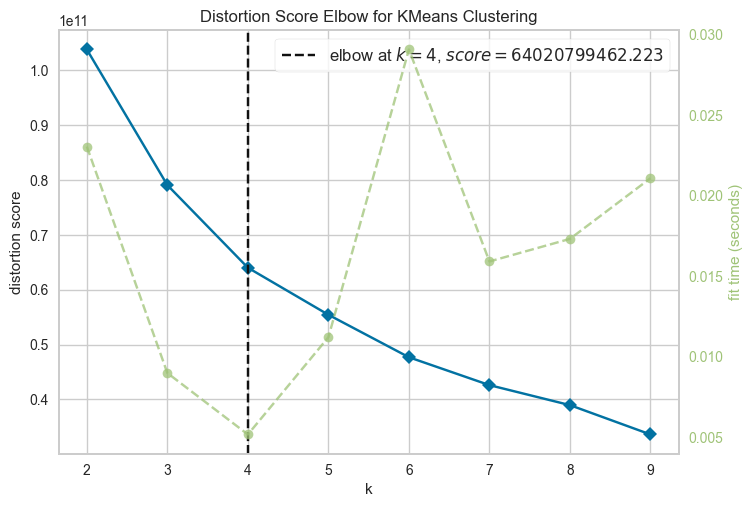

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [24]:
vis = KElbowVisualizer(KMeans(n_clusters=4, random_state=42), k=(2, 10), force_model=True)
vis.fit(df1)
vis.show()

In [25]:
model2=KMeans(4)

In [26]:
model2=model2.fit(df1)

In [27]:
tahmin2=model2.predict(df1)

In [28]:
silhouette_score(df1,tahmin2)

0.471372775554978

In [29]:
dump(model2, 'creditcard_clustering.joblib')

['creditcard_clustering.joblib']

In [30]:
data=linkage(df1,method='ward',metric='euclidean')

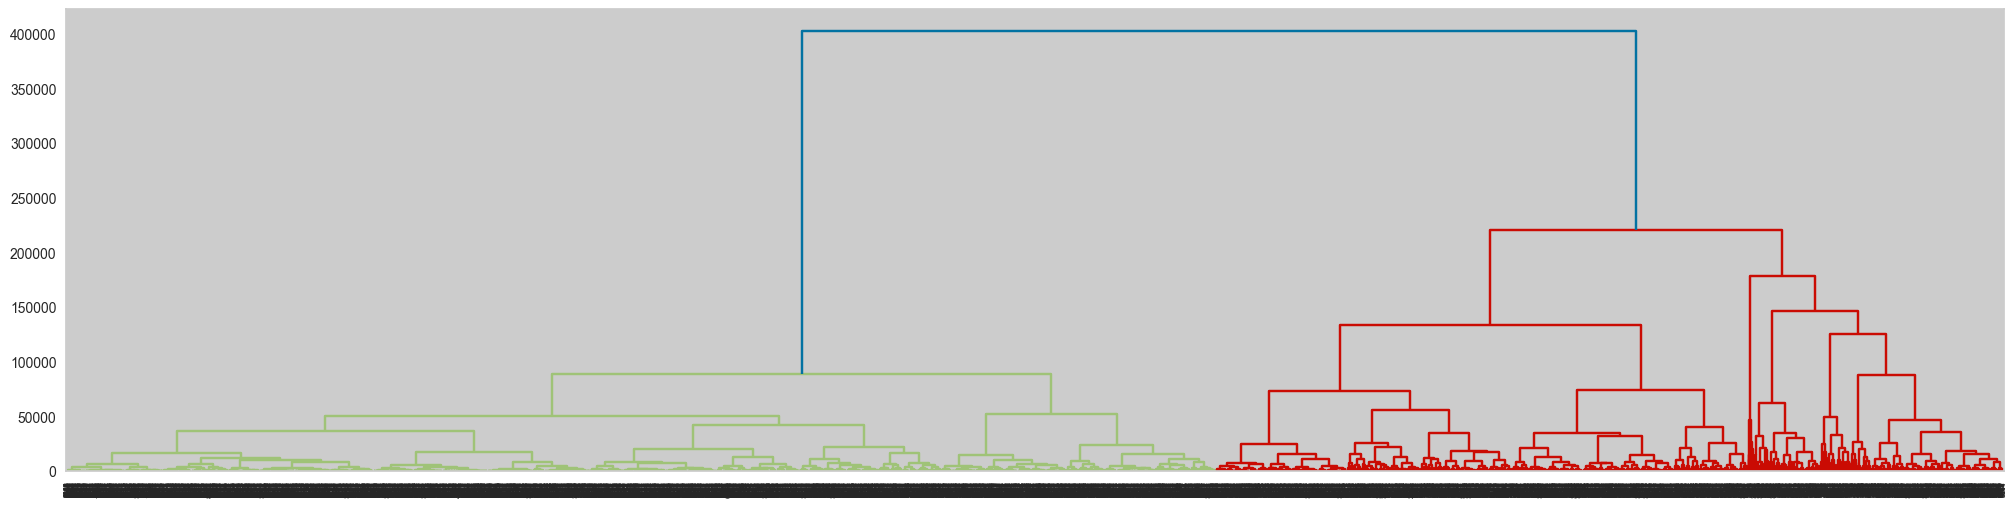

In [31]:
plt.figure(figsize=(25,6))
dendrogram(data);

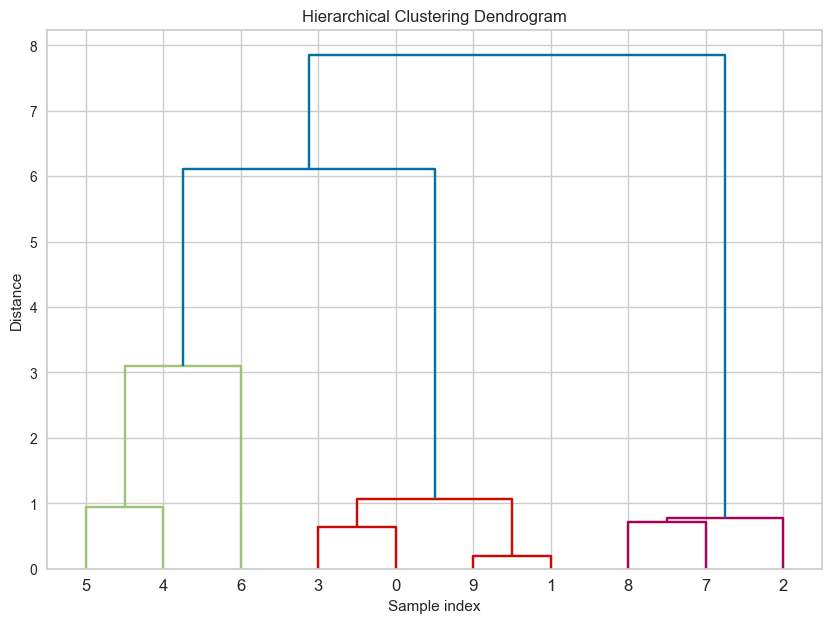

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate sample data
X, _ = make_blobs(n_samples=10, centers=3, cluster_std=0.60, random_state=0)

# Perform hierarchical clustering
linked = linkage(X, 'ward')

# Create a dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

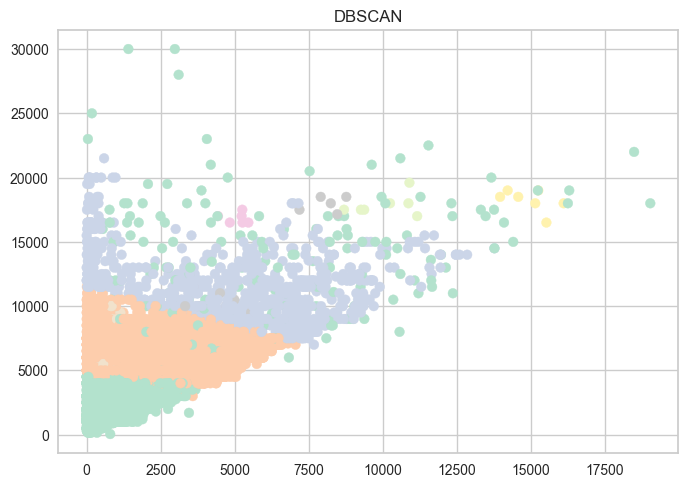

In [33]:
db=DBSCAN(min_samples=4)
from sklearn.preprocessing import StandardScaler
x2=StandardScaler().fit_transform(df1)
y=db.fit_predict(x2)
plt.title("DBSCAN")
plt.scatter(df['BALANCE'],df['CREDIT_LIMIT'],c=y,cmap='Pastel2');

### Deep Learning

In [34]:
scaler = StandardScaler()
df1_scaled = scaler.fit_transform(df1)

In [35]:
input_dim = df1_scaled.shape[1]  # input boyutu = 3
encoding_dim = 2                # gizli katmanda 2 boyut → görselleştirmek için

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)  # bottleneck layer

# Decoder
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)

# Autoencoder
autoencoder = Model(inputs=input_layer, outputs=decoded)

# Sadece encoder modeli
encoder = Model(inputs=input_layer, outputs=encoded)

# Compile ve fit
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(df1_scaled, df1_scaled, epochs=50, batch_size=16, shuffle=True, verbose=1)

Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4370
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3184
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2820
Epoch 4/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2499
Epoch 5/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2289
Epoch 6/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2210
Epoch 7/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2111
Epoch 8/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2070
Epoch 9/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1984
Epoch 10/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2001
Epoch 11/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1957
Epoch 12/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1923
Epoch 13/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1886
Epoch 14/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1857
Epoch 15/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

In [36]:
autoencoder.save('autoencoder_model.h5')

In [37]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df1)

In [38]:
df1_encoded = encoder.predict(df1_scaled)

270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


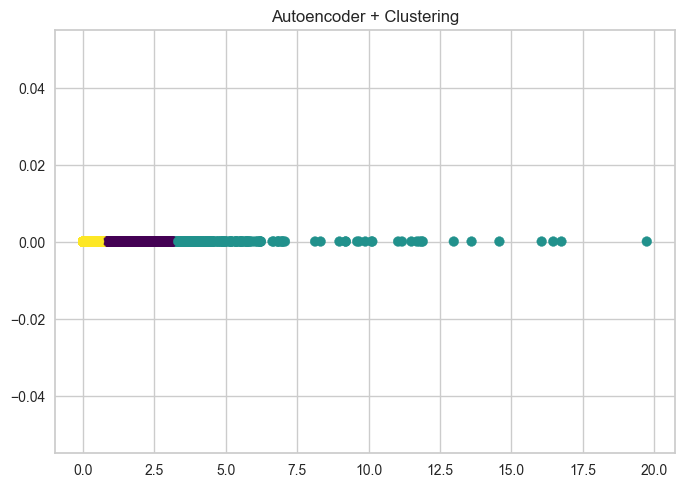

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(df1_encoded)

plt.figure()

plt.scatter(df1_encoded[:,0], df1_encoded[:,1], c=labels, cmap="viridis")

plt.title("Autoencoder + Clustering")
plt.show()